In [44]:
# Install libraries
!pip install rasterio
!pip install geopandas
# Load the data from the repository
!curl -L https://github.com/a-taylor1/DATA450_Team5/raw/f96e6ea78ed178af4fb4406b0d911c6bb98e1e0b/test_data.zip --output test_data.zip
!unzip -qo test_data.zip
%cd LF2024_EVC_CONUS/
# Print all of the files in the folder
!ls -l

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2814k  100 2814k    0     0  5556k      0 --:--:-- --:--:-- --:--:-- 5556k
/content/LF2024_EVC_CONUS/LF2024_EVC_CONUS/LF2024_EVC_CONUS
total 9560
-rwxrwxrwx 1 root root  103426 Apr  7 00:53 LF2024_EVC_CONUS.dbf
-rwxrwxrwx 1 root root     337 Apr  7 00:53 LF2024_EVC_CONUS.GeoJSON
-rwxrwxrwx 1 root root      93 Apr  7 00:53 LF2024_EVC_CONUS.tfw
-rwxrwxrwx 1 root root 6726706 Apr  7 00:53 LF2024_EVC_CONUS.tif
-rwxrwxrwx 1 root root 2819920 Apr  7 00:53 LF2024_EVC_CONUS.tif.ovr
-rwxrwxrwx 1 root root   62224 Apr  7 00:53 LF2024_EVC_CONUS.tif.vat.dbf
-rwxrwxrwx 1 root root    1622 Apr  7 00:53 metadata.dbf
-rwxrwxrwx 1 root root     459 Apr  7 00:53 metadata.prj
-rwxrwxrwx 1 root root    2132 Apr  7 00:53 metadata.shp
-rwxrwxrwx 1 root root     116 Apr  

In [45]:
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopandas import read_file

%matplotlib inline

In [46]:
# IMPORT DATAFRAME OF EV CODES
key_table:pd.DataFrame = read_file('LF2024_EVC_CONUS.dbf')
key_table = key_table.drop(columns = ['R', 'G', 'B', 'RED', 'GREEN', 'BLUE'])
key_table

,VALUE,CLASSNAMES
0,-9999,Fill-NoData
1,11,Open Water
2,12,Snow/Ice
3,13,Developed-Upland Deciduous Forest
4,14,Developed-Upland Evergreen Forest
...,...,...
288,395,Herb Cover = 95%
289,396,Herb Cover = 96%
290,397,Herb Cover = 97%
291,398,Herb Cover = 98%


### **SORT CLASSNMES INTO UNIQUE COLUMNS**

In [47]:
# 1. Get all levels of CLASSNAMES
class_levels = key_table['CLASSNAMES'].to_list()

In [48]:
# 2. Separate continuous and discrete classes
#   NOTE: The dataframe represents continuous classes in the form "class name = xx%"
continuous_classes = []
discrete_classes = []
for c in class_levels:
  try:
    c.index('=')
    continuous_classes.append(c)
  except:
    discrete_classes.append(c)
print(f'CONTINUOUS:\n{continuous_classes[1:10]}')
print(f'CONTINUOUS:\n{discrete_classes[1:10]}')

CONTINUOUS:
['Tree Cover = 11%', 'Tree Cover = 12%', 'Tree Cover = 13%', 'Tree Cover = 14%', 'Tree Cover = 15%', 'Tree Cover = 16%', 'Tree Cover = 17%', 'Tree Cover = 18%', 'Tree Cover = 19%']
CONTINUOUS:
['Open Water', 'Snow/Ice', 'Developed-Upland Deciduous Forest', 'Developed-Upland Evergreen Forest', 'Developed-Upland Mixed Forest', 'Developed-Upland Herbaceous', 'Developed-Upland Shrubland', 'Developed - Open Space', 'Developed-Low Intensity']


In [49]:
continuous_formatted = []
discrete_formatted = []
# 3. Create columns for continuous classes
def translate_classname(name:str) -> tuple[str, str]:
  split_c = [name]
  if name in continuous_classes:
    if ' = ' in name: split_c = name.split(' = ')
    elif ' >= ' in name: split_c = name.split(' >= ')
    split_c[0] = split_c[0].replace(' ', '_')
    split_c[1] = int(split_c[1].replace('%', ''))
    continuous_formatted.append(split_c[0])
  else:
    split_c[0] = name.replace(' ', '_')
    split_c.append(True)
    discrete_formatted.append(split_c[0])
  return tuple(split_c)

def extract_classname(name:str) -> str:
  return translate_classname(name)[0] # Removed .lower() to match list casings

def extract_value(name:str) -> int|bool:
  return translate_classname(name)[1]

key_table['class_name'] = key_table['CLASSNAMES'].apply(extract_classname).rename('class_name')
key_table['class_value'] = key_table['CLASSNAMES'].apply(extract_value).rename('class_value')
key_table


,VALUE,CLASSNAMES,class_name,class_value
0,-9999,Fill-NoData,Fill-NoData,True
1,11,Open Water,Open_Water,True
2,12,Snow/Ice,Snow/Ice,True
3,13,Developed-Upland Deciduous Forest,Developed-Upland_Deciduous_Forest,True
4,14,Developed-Upland Evergreen Forest,Developed-Upland_Evergreen_Forest,True
...,...,...,...,...
288,395,Herb Cover = 95%,Herb_Cover,95
289,396,Herb Cover = 96%,Herb_Cover,96
290,397,Herb Cover = 97%,Herb_Cover,97
291,398,Herb Cover = 98%,Herb_Cover,98


In [50]:
def name_by_evcode (code:int) -> str:
  return key_table[key_table['VALUE'] == code].iloc[0]['class_name']
def value_by_evcode (code:int) -> int|bool:
  return key_table[key_table['VALUE'] == code].iloc[0]['class_value']

In [51]:
import rasterio
import numpy as np
import pandas as pd

# 1. First, create map_df by reading the raster
with rasterio.open('LF2024_EVC_CONUS.tif') as src:
    band = src.read(1)
    transform = src.transform
    cols, rows = np.meshgrid(np.arange(src.width), np.arange(src.height))
    xs, ys = transform * (cols, rows)

map_df = pd.DataFrame({
    'x': xs.flatten(),
    'y': ys.flatten(),
    'VALUE': band.flatten()
})

# 2. Check the raster's official NoData value

# 3. Find unique values in our map dataframe
unique_map_values = map_df['VALUE'].unique()

# 4. Find which values are missing from the key_table
missing_from_key = set(unique_map_values) - set(key_table['VALUE'])

# 5. Map the raster's NoData value (32767) to the key_table's NoData value (-9999)
map_df['VALUE'] = map_df['VALUE'].replace(32767, -9999)
display(map_df.head())


,x,y,VALUE
0,-853005.0,2785185.0,-9999
1,-852975.0,2785185.0,-9999
2,-852945.0,2785185.0,-9999
3,-852915.0,2785185.0,-9999
4,-852885.0,2785185.0,-9999


In [52]:
# Create a quick mapping from VALUE to class_name
code_to_name = dict(zip(key_table['VALUE'], key_table['class_name']))

# Map the names to a new column in map_df for fast grouping
map_df['class_name'] = map_df['VALUE'].map(code_to_name)

# Group by class_name and create a dictionary of dataframes
frames = {name: group for name, group in map_df.groupby('class_name')}

# Test with a known class name, e.g., 'open_water'
display( frames.get('open_water', pd.DataFrame()).head() )


""


In [53]:
# Recreate new_df from map_df
new_df = pd.DataFrame({
    'X': map_df['x'],
    'Y': map_df['y'],
    'EVCODE': map_df['VALUE']
})

# Initialize columns based on continuous and discrete lists
for c in continuous_formatted:
    new_df[c] = 0
for c in discrete_formatted:
    new_df[c] = False

# Create dictionaries for quick mapping
code_to_name = dict(zip(key_table['VALUE'], key_table['class_name']))
code_to_value = dict(zip(key_table['VALUE'], key_table['class_value']))

# Vectorized approach: update columns in bulk for each unique EVCODE
for code in new_df['EVCODE'].unique():
    if code in code_to_name:
        col_name = code_to_name[code]
        col_val = code_to_value[code]
        # Assign the value to the corresponding column for all rows with this EVCODE
        new_df.loc[new_df['EVCODE'] == code, col_name] = col_val

display(new_df.head())


,X,Y,EVCODE,Tree_Cover,Shrub_Cover,Herb_Cover,Fill-NoData,Open_Water,Snow/Ice,Developed-Upland_Deciduous_Forest,...,Barren,Quarries-Strip_Mines-Gravel_Pits-Well_and_Wind_Pads,NASS-Vineyard,NASS-Row_Crop-Close_Grown_Crop,NASS-Row_Crop,NASS-Close_Grown_Crop,NASS-Wheat,NASS-Aquaculture,Cultivated_Crops,Sparse_Vegetation_Canopy
0,-853005.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-852975.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-852945.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-852915.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-852885.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [54]:
# Standardize column naming
new_col_names = {}
for c in new_df.columns:
  result = c
  symbols = []
  for character in c:
    if( (not str(character).isalnum()) and (not character.isspace()) ):
      symbols.append(character)
  for s in symbols:
    result = result.replace(s, '-')
  result = [r.capitalize() for r in result.split('-') if r != '']
  result_str = ''.join(result)
  new_col_names[c] = result_str
new_df_renamed = new_df.rename(columns = new_col_names)
new_df_renamed.head()

,X,Y,Evcode,TreeCover,ShrubCover,HerbCover,FillNodata,OpenWater,SnowIce,DevelopedUplandDeciduousForest,...,Barren,QuarriesStripMinesGravelPitsWellAndWindPads,NassVineyard,NassRowCropCloseGrownCrop,NassRowCrop,NassCloseGrownCrop,NassWheat,NassAquaculture,CultivatedCrops,SparseVegetationCanopy
0,-853005.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-852975.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-852945.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-852915.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-852885.0,2785185.0,-9999,0,0,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [62]:
# Drop rows with no data (edge rows)
new_df_dropped = new_df_renamed[ new_df_renamed['Evcode'] != -9999]
new_df_dropped = new_df_dropped.drop(columns = ['FillNodata'])
new_df_dropped

,X,Y,Evcode,TreeCover,ShrubCover,HerbCover,OpenWater,SnowIce,DevelopedUplandDeciduousForest,DevelopedUplandEvergreenForest,...,Barren,QuarriesStripMinesGravelPitsWellAndWindPads,NassVineyard,NassRowCropCloseGrownCrop,NassRowCrop,NassCloseGrownCrop,NassWheat,NassAquaculture,CultivatedCrops,SparseVegetationCanopy
190,-847305.0,2785185.0,332,0,0,32,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
191,-847275.0,2785185.0,349,0,0,49,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
192,-847245.0,2785185.0,348,0,0,48,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
193,-847215.0,2785185.0,349,0,0,49,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
194,-847185.0,2785185.0,349,0,0,49,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3360133,-802365.0,2731335.0,342,0,0,42,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3360134,-802335.0,2731335.0,343,0,0,43,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3360135,-802305.0,2731335.0,344,0,0,44,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3360136,-802275.0,2731335.0,338,0,0,38,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [63]:
for i in new_df_dropped.dtypes.value_counts().index:
  print( f'COLUMNS OF TYPE <{i}>' )
  print( new_df_dropped.select_dtypes(str(i)).columns.values )

COLUMNS OF TYPE <bool>
['OpenWater' 'SnowIce' 'DevelopedUplandDeciduousForest'
 'DevelopedUplandEvergreenForest' 'DevelopedUplandMixedForest'
 'DevelopedUplandHerbaceous' 'DevelopedUplandShrubland'
 'DevelopedOpenSpace' 'DevelopedLowIntensity' 'DevelopedMediumIntensity'
 'DevelopedHighIntensity' 'DevelopedRoads' 'Barren'
 'QuarriesStripMinesGravelPitsWellAndWindPads' 'NassVineyard'
 'NassRowCropCloseGrownCrop' 'NassRowCrop' 'NassCloseGrownCrop'
 'NassWheat' 'NassAquaculture' 'CultivatedCrops' 'SparseVegetationCanopy']
COLUMNS OF TYPE <int64>
['TreeCover' 'ShrubCover' 'HerbCover']
COLUMNS OF TYPE <float64>
['X' 'Y']
COLUMNS OF TYPE <int16>
['Evcode']


The dataset has bool columns and numeric columns.

In [64]:
df_dummies = pd.get_dummies(data = new_df_dropped, prefix = '_', drop_first = True)
df_dummies.head()

,X,Y,Evcode,TreeCover,ShrubCover,HerbCover,OpenWater,SnowIce,DevelopedUplandDeciduousForest,DevelopedUplandEvergreenForest,...,Barren,QuarriesStripMinesGravelPitsWellAndWindPads,NassVineyard,NassRowCropCloseGrownCrop,NassRowCrop,NassCloseGrownCrop,NassWheat,NassAquaculture,CultivatedCrops,SparseVegetationCanopy
190,-847305.0,2785185.0,332,0,0,32,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
191,-847275.0,2785185.0,349,0,0,49,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
192,-847245.0,2785185.0,348,0,0,48,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
193,-847215.0,2785185.0,349,0,0,49,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
194,-847185.0,2785185.0,349,0,0,49,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


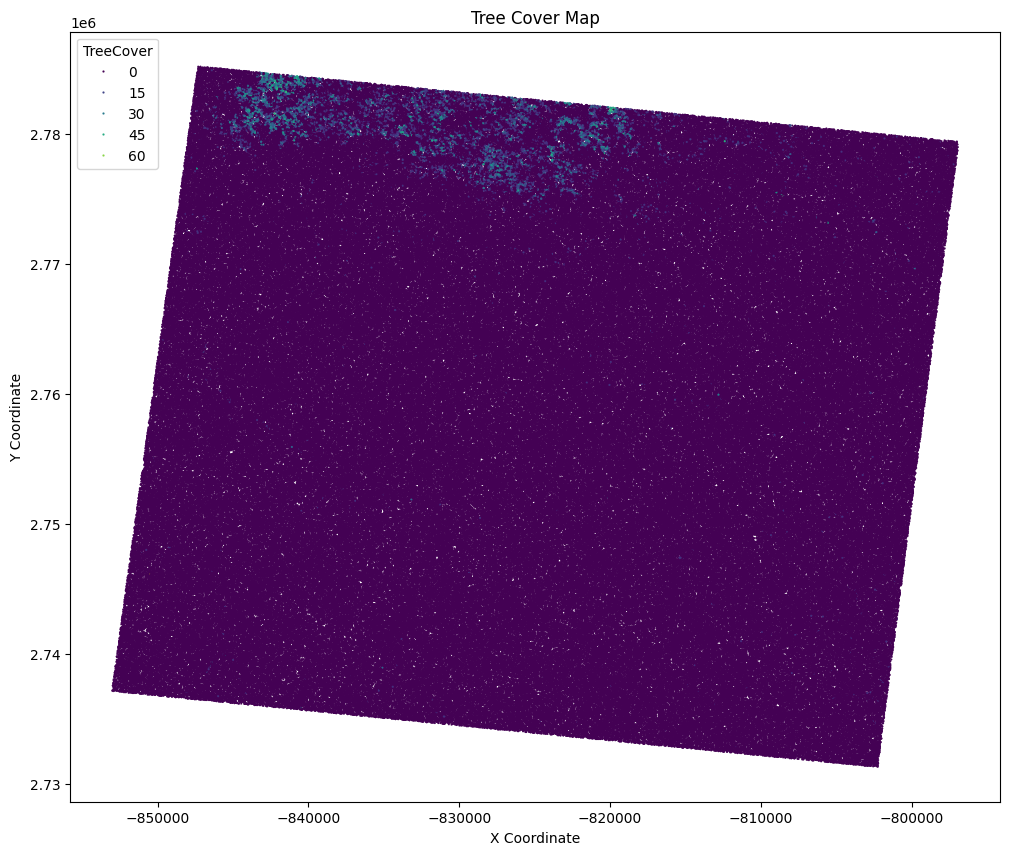

In [66]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data = df_dummies.sample(n = int(len(df_dummies)*0.2)),
    x = 'X', y = 'Y',
    hue = 'TreeCover',
    palette = 'viridis',
    s = 2, edgecolor = None
)
plt.title('Tree Cover Map')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


In [86]:
# Get summaries of each column to identify columns with only one value
single_val_cols = []
clean_df_cols = []
for c in df_dummies.columns:
  if len(df_dummies[c].value_counts()) == 1: single_val_cols.append(c)
  else: clean_df_cols.append(c)
clean_df = df_dummies[clean_df_cols].reset_index(drop = True).drop(columns = ['Evcode'])
clean_df.head()


,X,Y,TreeCover,ShrubCover,HerbCover,OpenWater,DevelopedUplandDeciduousForest,DevelopedUplandEvergreenForest,DevelopedUplandHerbaceous,DevelopedUplandShrubland,DevelopedLowIntensity,DevelopedMediumIntensity,DevelopedHighIntensity,DevelopedRoads,Barren,NassRowCropCloseGrownCrop,NassRowCrop,NassCloseGrownCrop,NassWheat,SparseVegetationCanopy
0,-847305.0,2785185.0,0,0,32,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,-847275.0,2785185.0,0,0,49,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,-847245.0,2785185.0,0,0,48,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,-847215.0,2785185.0,0,0,49,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,-847185.0,2785185.0,0,0,49,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [115]:
clean_df['xStandard'] = (clean_df['X'] - clean_df['X'].min()) / (clean_df['X'].max() - clean_df['X'].min())
clean_df['yStandard'] = (clean_df['Y'] - clean_df['Y'].min()) / (clean_df['Y'].max() - clean_df['Y'].min())

clean_df

,X,Y,TreeCover,ShrubCover,HerbCover,OpenWater,DevelopedUplandDeciduousForest,DevelopedUplandEvergreenForest,DevelopedUplandHerbaceous,DevelopedUplandShrubland,...,Barren,NassRowCropCloseGrownCrop,NassRowCrop,NassCloseGrownCrop,NassWheat,SparseVegetationCanopy,xStandard,yStandard,xBin,yBin
0,-847305.0,2785185.0,0,0,32,False,False,False,False,False,...,False,False,False,False,False,False,0.101604,1.0,x17,y300
1,-847275.0,2785185.0,0,0,49,False,False,False,False,False,...,False,False,False,False,False,False,0.102139,1.0,x18,y300
2,-847245.0,2785185.0,0,0,48,False,False,False,False,False,...,False,False,False,False,False,False,0.102674,1.0,x18,y300
3,-847215.0,2785185.0,0,0,49,False,False,False,False,False,...,False,False,False,False,False,False,0.103209,1.0,x18,y300
4,-847185.0,2785185.0,0,0,49,False,False,False,False,False,...,False,False,False,False,False,False,0.103743,1.0,x18,y300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2739635,-802365.0,2731335.0,0,0,42,False,False,False,False,False,...,False,False,False,False,False,False,0.902674,0.0,x284,y1
2739636,-802335.0,2731335.0,0,0,43,False,False,False,False,False,...,False,False,False,False,False,False,0.903209,0.0,x284,y1
2739637,-802305.0,2731335.0,0,0,44,False,False,False,False,False,...,False,False,False,False,False,False,0.903743,0.0,x284,y1
2739638,-802275.0,2731335.0,0,0,38,False,False,False,False,False,...,False,False,False,False,False,False,0.904278,0.0,x284,y1


In [116]:
import matplotlib.pyplot as plt
import numpy as np

def hexplot_column(column_name:str, alt_title:str = None):
  if alt_title == None: alt_title = column_name
  plt.figure(figsize=(12, 10))
  # Using C to aggregate TreeCover values with mean function
  hb = plt.hexbin(
      x = clean_df['X'],
      y = clean_df['Y'],
      C = clean_df[column_name],
      reduce_C_function = np.mean,
      gridsize = 100,
      cmap = 'Greens',
      mincnt = 1
  )
  plt.colorbar(hb, label = f'Average {alt_title}')
  plt.title(f'2D Hexbin Map of Average {alt_title}')
  plt.xlabel('X Coordinate')
  plt.ylabel('Y Coordinate')
  plt.show()

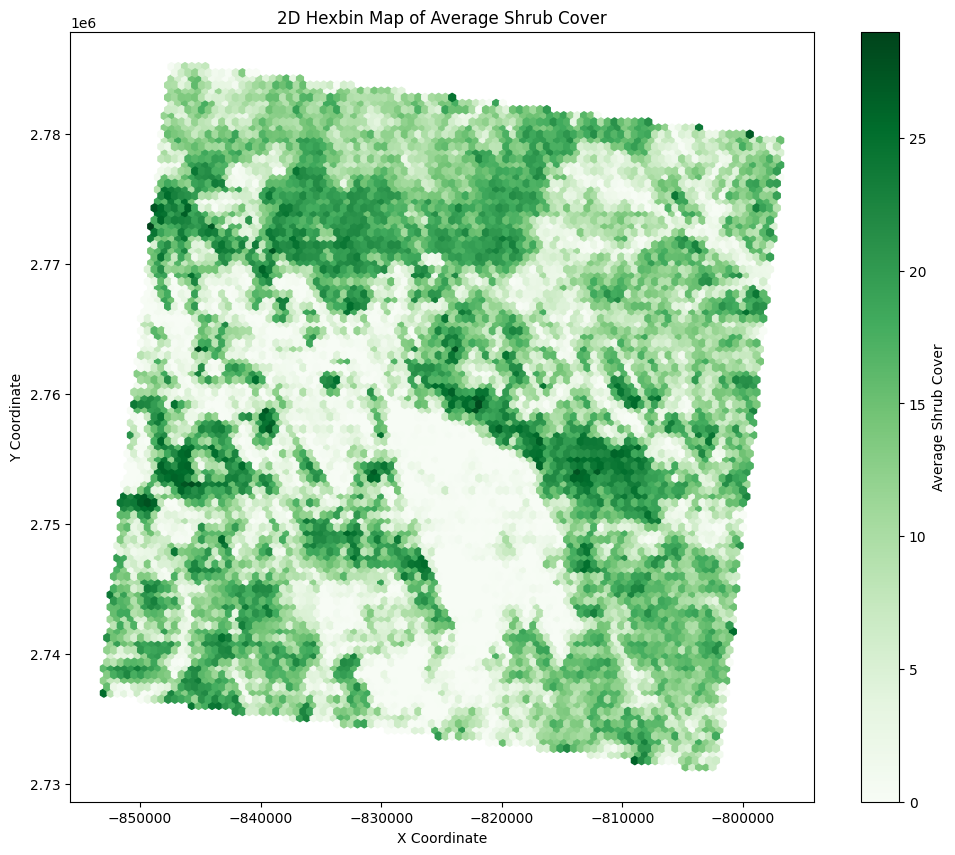

In [112]:
hexplot_column('ShrubCover', 'Shrub Cover')

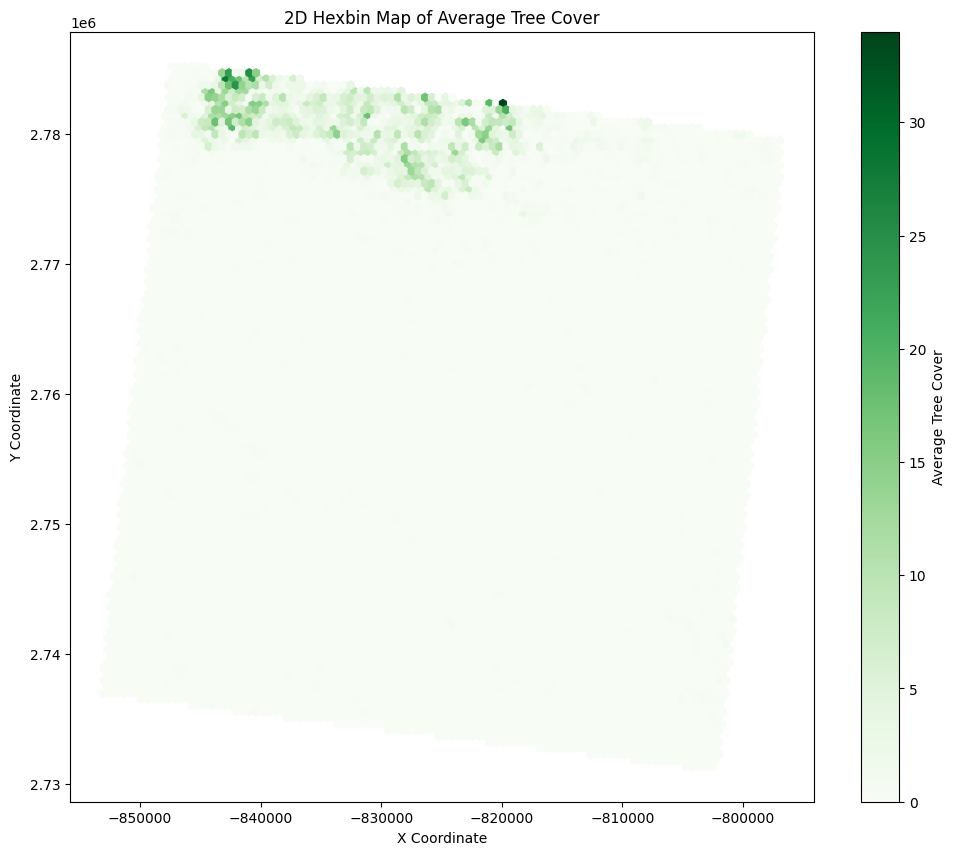

In [113]:
hexplot_column('TreeCover', 'Tree Cover')

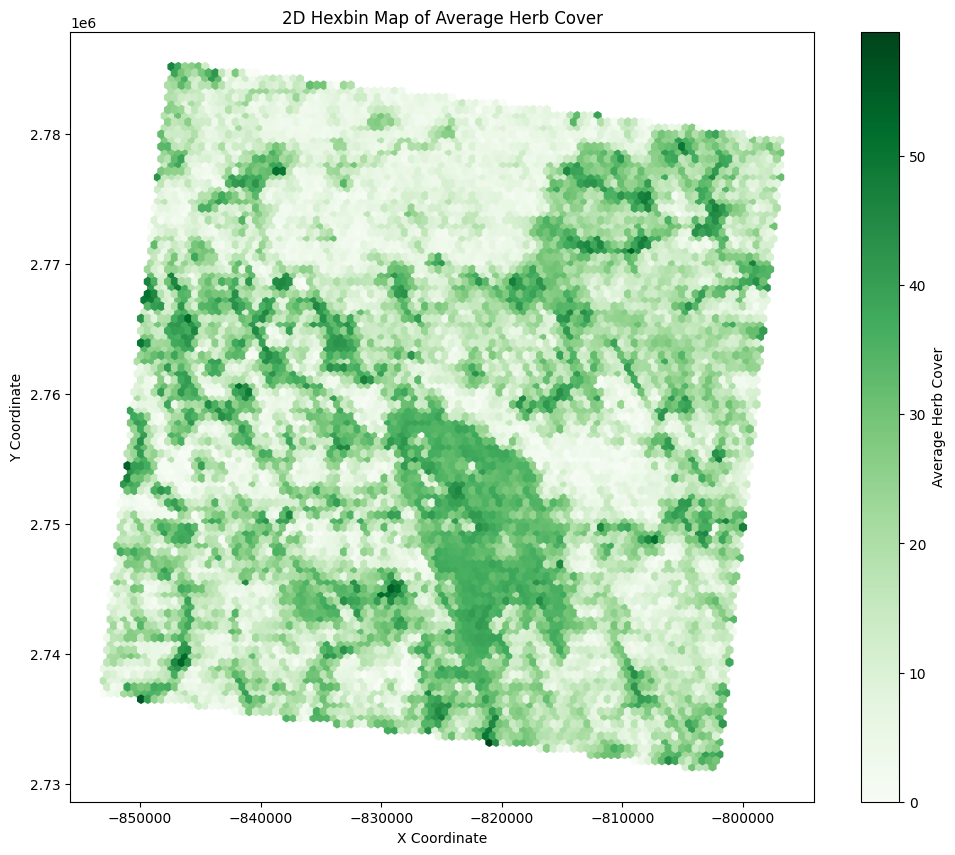

In [114]:
hexplot_column('HerbCover', 'Herb Cover')